## 1. Import thư viện

Sử dụng đúng nhóm thư viện trong bài gốc: `numpy`, `pandas`, `matplotlib`, `seaborn`, `scikit-learn`.

Nếu môi trường chưa có thư viện, cài nhanh bằng:
`pip install numpy pandas matplotlib seaborn scikit-learn notebook`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

import warnings
warnings.filterwarnings('ignore')


## 2. Đọc dữ liệu

Bạn đã có file `new.csv` ở thư mục gốc `machine-learning-2026`, nên từ notebook này ta đọc qua đường dẫn tương đối `../new.csv`.

In [2]:
df = pd.read_csv('../new.csv')
df.head()


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [3]:
print('Kich thuoc du lieu:', df.shape)
df.info()


Kich thuoc du lieu: (2240, 29)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDeal

In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
ID,2240.0,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,1968.805804,11.984069,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.251354,25173.076661,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2240.0,0.444196,0.538398,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.506250,0.544538,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.302232,39.773434,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.950000,225.715373,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.525446,54.628979,0.0,3.00,12.0,50.00,259.0


## 3. Tiền xử lý dữ liệu

Các bước bám theo bài gốc:
- kiểm tra thiếu dữ liệu,
- loại bỏ dòng thiếu,
- tách cột ngày `Dt_Customer` thành `day`, `month`, `year`,
- bỏ các cột ít ý nghĩa cho phân cụm.

In [5]:
for col in df.columns:
    temp = df[col].isnull().sum()
    if temp > 0:
        print(f'Column {col} contains {temp} null values.')


Column Income contains 24 null values.


In [6]:
df = df.dropna().copy()
print('Tong so dong sau khi bo null:', len(df))


Tong so dong sau khi bo null: 2216


In [7]:
df.nunique()


ID                     2216
Year_Birth               59
Education                 5
Marital_Status            8
Income                 1974
Kidhome                   3
Teenhome                  3
Dt_Customer             662
Recency                 100
MntWines                776
MntFruits               158
MntMeatProducts         554
MntFishProducts         182
MntSweetProducts        176
MntGoldProds            212
NumDealsPurchases        15
NumWebPurchases          15
NumCatalogPurchases      14
NumStorePurchases        14
NumWebVisitsMonth        16
AcceptedCmp3              2
AcceptedCmp4              2
AcceptedCmp5              2
AcceptedCmp1              2
AcceptedCmp2              2
Complain                  2
Z_CostContact             1
Z_Revenue                 1
Response                  2
dtype: int64

In [8]:
parts = df['Dt_Customer'].str.split('-', n=2, expand=True)
df['day'] = parts[0].astype(int)
df['month'] = parts[1].astype(int)
df['year'] = parts[2].astype(int)

df.drop(['Z_CostContact', 'Z_Revenue', 'Dt_Customer'], axis=1, inplace=True)
df.head()


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,day,month,year
0,5524,1957,Graduation,Single,58138.0,0,0,58,635,88,...,0,0,0,0,0,0,1,4,9,2012
1,2174,1954,Graduation,Single,46344.0,1,1,38,11,1,...,0,0,0,0,0,0,0,8,3,2014
2,4141,1965,Graduation,Together,71613.0,0,0,26,426,49,...,0,0,0,0,0,0,0,21,8,2013
3,6182,1984,Graduation,Together,26646.0,1,0,26,11,4,...,0,0,0,0,0,0,0,10,2,2014
4,5324,1981,PhD,Married,58293.0,1,0,94,173,43,...,0,0,0,0,0,0,0,19,1,2014


## 4. Trực quan hóa

Tách cột kiểu `object` và `float` để xem phân phối cơ bản trước khi mã hóa.

In [9]:
floats, objects = [], []
for col in df.columns:
    if df[col].dtype == object:
        objects.append(col)
    elif df[col].dtype == float:
        floats.append(col)

print('Object columns:', objects)
print('Float columns:', floats)


Object columns: ['Education', 'Marital_Status']
Float columns: ['Income']


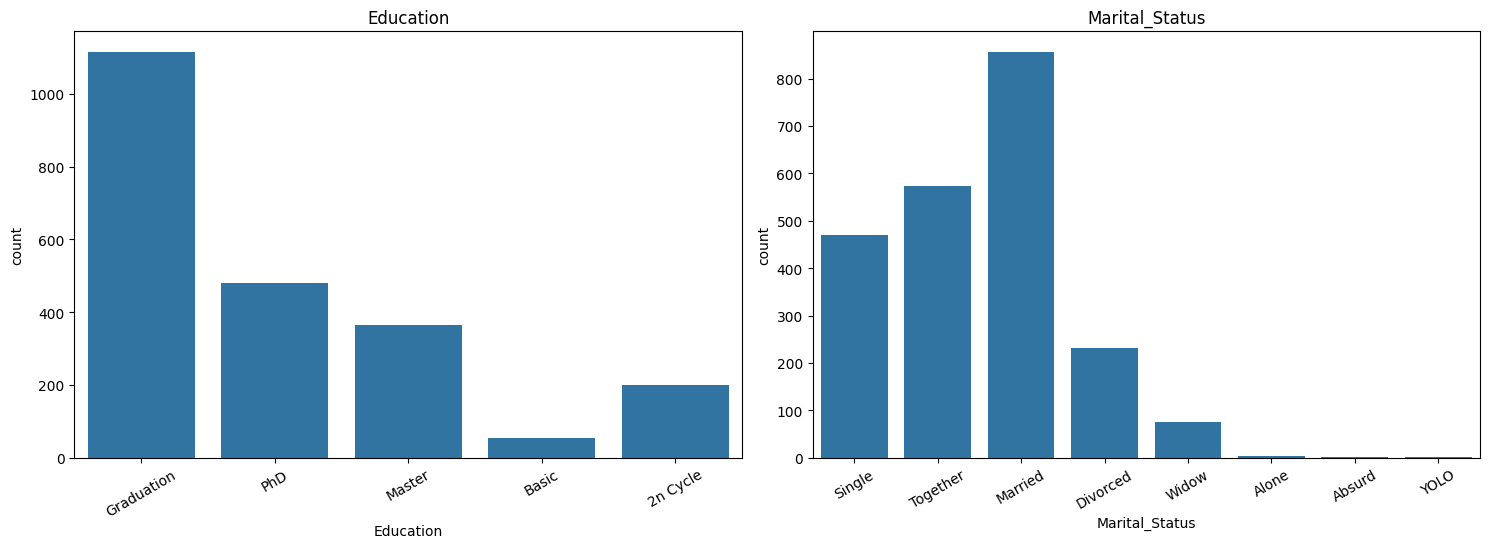

In [10]:
if len(objects) > 0:
    plt.figure(figsize=(15, 10))
    for i, col in enumerate(objects):
        plt.subplot(2, 2, i + 1)
        sb.countplot(x=df[col])
        plt.xticks(rotation=30)
        plt.title(col)
    plt.tight_layout()
    plt.show()


In [11]:
print(df['Marital_Status'].value_counts())


Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64


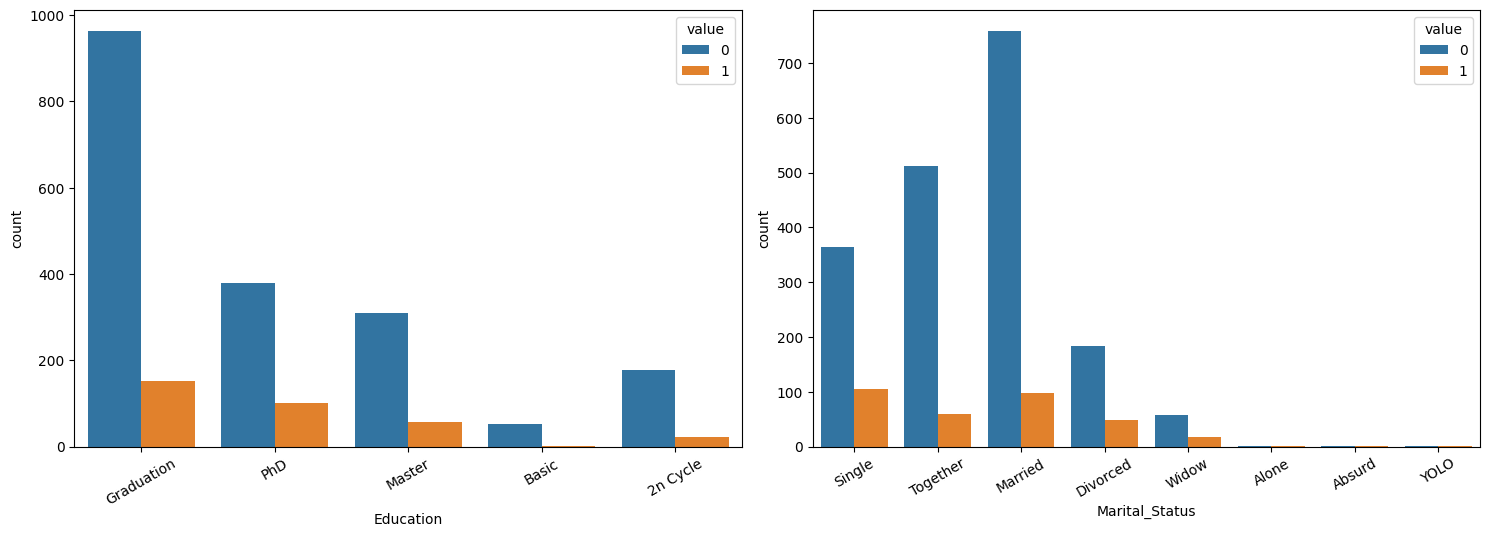

In [12]:
if 'Response' in df.columns and len(objects) > 0:
    plt.figure(figsize=(15, 10))
    for i, col in enumerate(objects):
        plt.subplot(2, 2, i + 1)
        df_melted = df.melt(id_vars=[col], value_vars=['Response'], var_name='hue')
        sb.countplot(x=col, hue='value', data=df_melted)
        plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


## 5. Label Encoding + Correlation + Standardization

Mã hóa cột phân loại để mô hình xử lý được, sau đó kiểm tra tương quan cao và chuẩn hóa đặc trưng.

In [13]:
for col in df.columns:
    if df[col].dtype == object:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])

df.head()


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,day,month,year
0,5524,1957,2,4,58138.0,0,0,58,635,88,...,0,0,0,0,0,0,1,4,9,2012
1,2174,1954,2,4,46344.0,1,1,38,11,1,...,0,0,0,0,0,0,0,8,3,2014
2,4141,1965,2,5,71613.0,0,0,26,426,49,...,0,0,0,0,0,0,0,21,8,2013
3,6182,1984,2,5,26646.0,1,0,26,11,4,...,0,0,0,0,0,0,0,10,2,2014
4,5324,1981,4,3,58293.0,1,0,94,173,43,...,0,0,0,0,0,0,0,19,1,2014


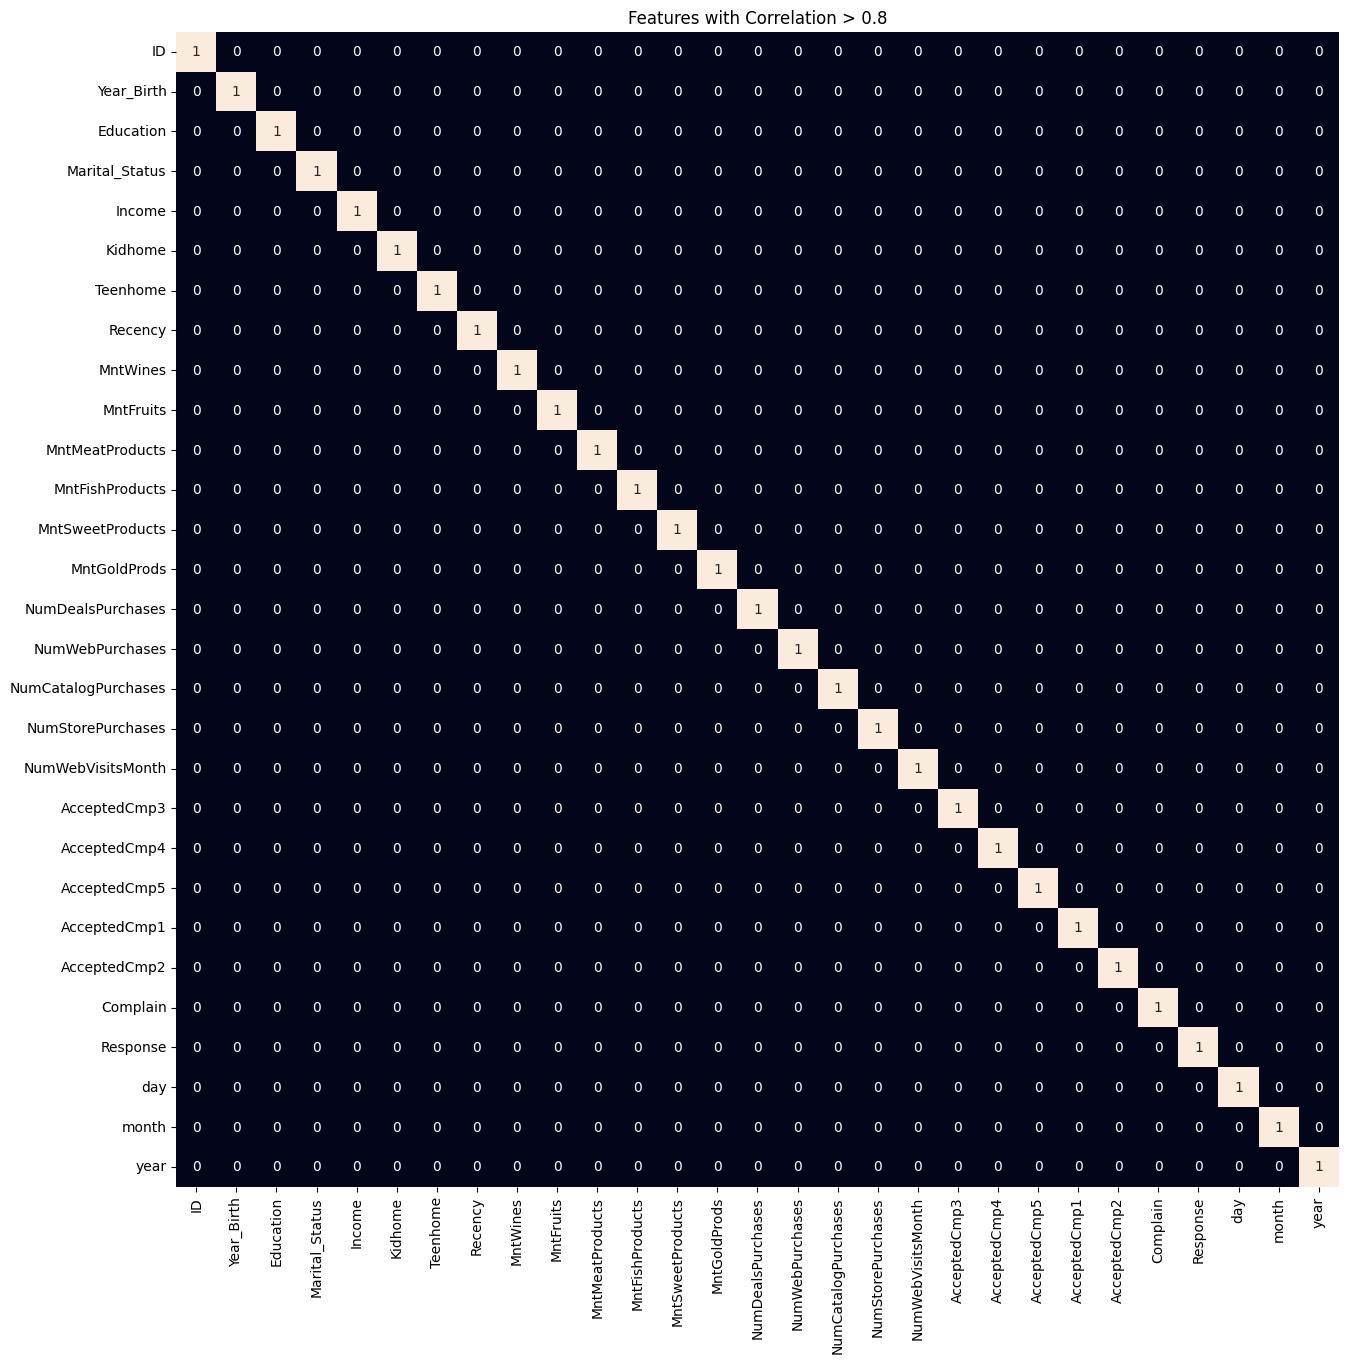

In [14]:
plt.figure(figsize=(15, 15))
sb.heatmap(df.corr() > 0.8, annot=True, cbar=False)
plt.title('Features with Correlation > 0.8')
plt.show()


In [15]:
scaler = StandardScaler()
data = scaler.fit_transform(df)
print('Scaled data shape:', data.shape)


Scaled data shape: (2216, 29)


## 6. t-SNE để nhìn cấu trúc cụm

t-SNE giảm chiều dữ liệu về 2D để ta quan sát trực quan dữ liệu có xu hướng tạo cụm ra sao.

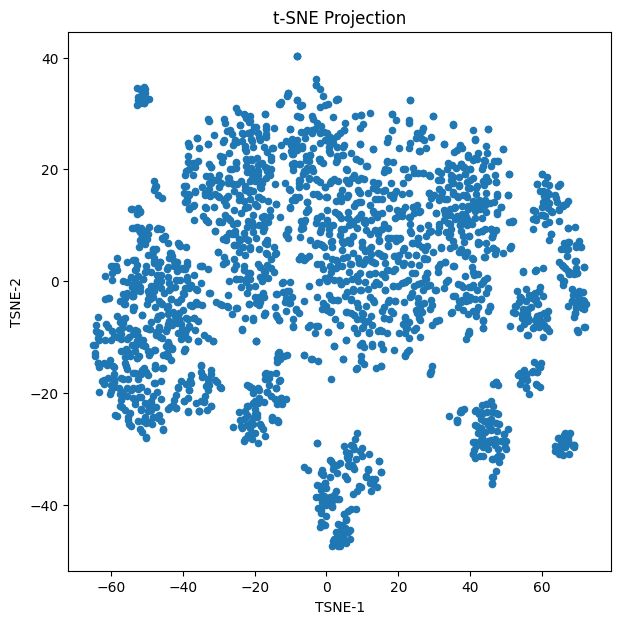

In [16]:
model_tsne = TSNE(n_components=2, random_state=0)
tsne_data = model_tsne.fit_transform(data)

plt.figure(figsize=(7, 7))
plt.scatter(tsne_data[:, 0], tsne_data[:, 1], s=20)
plt.title('t-SNE Projection')
plt.xlabel('TSNE-1')
plt.ylabel('TSNE-2')
plt.show()


## 7. Elbow Method + KMeans Segmentation

Tính inertia từ `k=1` đến `k=20`, sau đó chọn số cụm hợp lý theo điểm gãy (elbow).

Trong bài gốc, phần giải thích nói khoảng `k=6`, nhưng đoạn code cuối cùng dùng `n_clusters=5`. Notebook này giữ theo code mẫu của bài để bạn đối chiếu dễ hơn.

In [17]:
error = []
for n_clusters in range(1, 21):
    model = KMeans(
        init='k-means++',
        n_clusters=n_clusters,
        max_iter=500,
        random_state=22,
        n_init=10
    )
    model.fit(data)
    error.append(model.inertia_)


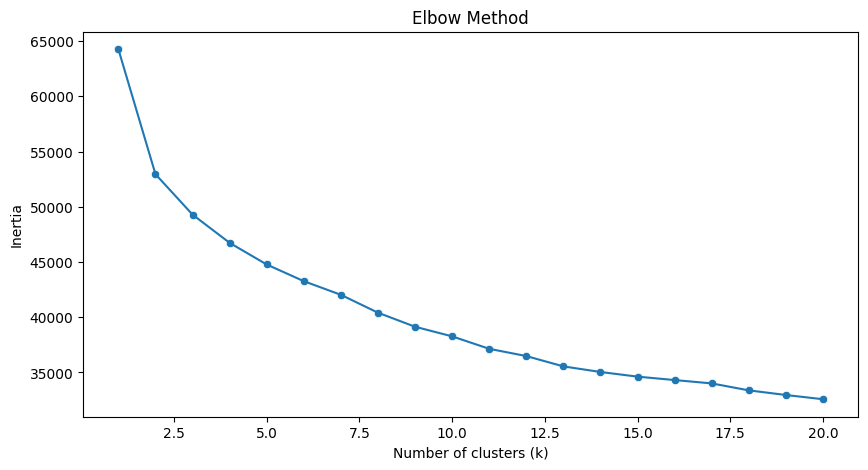

In [18]:
plt.figure(figsize=(10, 5))
sb.lineplot(x=range(1, 21), y=error)
sb.scatterplot(x=range(1, 21), y=error)
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()


In [19]:
model = KMeans(
    init='k-means++',
    n_clusters=5,
    max_iter=500,
    random_state=22,
    n_init=10
)
segments = model.fit_predict(data)

print('So cum tao duoc:', len(np.unique(segments)))
print('So mau moi cum:')
print(pd.Series(segments).value_counts().sort_index())


So cum tao duoc: 5
So mau moi cum:
0    999
1    551
2    195
3    441
4     30
Name: count, dtype: int64


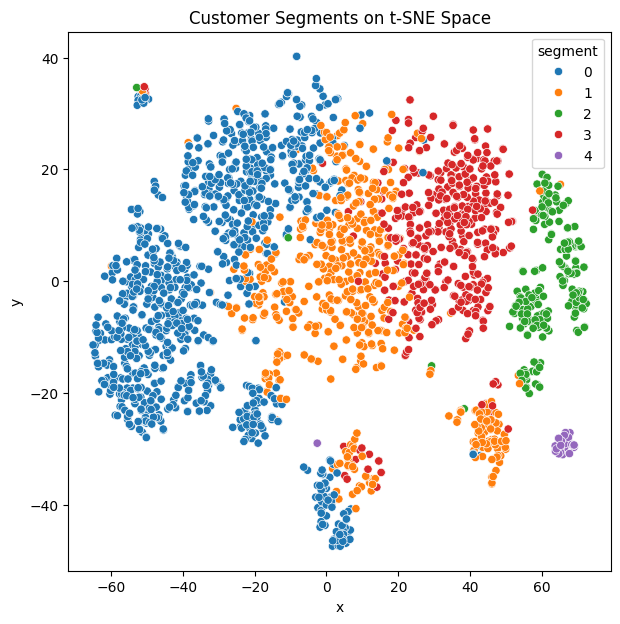

In [20]:
plt.figure(figsize=(7, 7))
df_tsne = pd.DataFrame({'x': tsne_data[:, 0], 'y': tsne_data[:, 1], 'segment': segments})
sb.scatterplot(x='x', y='y', hue='segment', palette='tab10', data=df_tsne)
plt.title('Customer Segments on t-SNE Space')
plt.show()


## 8. Tóm tắt nhanh theo cụm

Bổ sung một bảng thống kê nhỏ để bạn đọc ý nghĩa kinh doanh theo từng cụm.

In [21]:
df_result = df.copy()
df_result['segment'] = segments

summary_cols = [
    'Income', 'MntWines', 'MntMeatProducts',
    'NumWebPurchases', 'NumStorePurchases', 'Recency'
]

available_cols = [c for c in summary_cols if c in df_result.columns]
df_result.groupby('segment')[available_cols].mean().round(2)


,Income,MntWines,MntMeatProducts,NumWebPurchases,NumStorePurchases,Recency
segment,,,,,,
0,34589.51,38.86,22.77,2.08,3.16,49.20
1,56529.71,441.92,123.74,6.26,7.40,48.22
2,84429.56,794.66,489.25,5.51,8.22,49.43
3,71387.09,480.39,399.59,5.23,8.55,49.43
4,71054.83,898.67,250.30,4.90,8.17,48.67
